# <img style="float: left; padding-right: 20px; width: 200px" src="https://raw.githubusercontent.com/raxlab/imt2200-data/main/media/logo.jpg">  IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

# <h1><center>Tarea 03: Exploración de datos </center></h1>

**Fecha de Entrega:** 28 de octubre de 2025, a las 23:59.

**Fecha de publicación**: 14 de octubre de 2025.

**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 03 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tarea.

- Deben hacer sus consultas y comentarios sobre la Tarea a través del canal de Tareas en el Foro del curso en Canvas.

---

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

En esta tarea vamos a analizar la distribución de vulneribilidad escolar para distintos establecimientos educacionales en Chile, desde enseñanza parvularia hasta enseñanza media. Específicamente, queremos entender cómo se comporta un índice de vulnerabilidad en relación a variables como ruralidad, tipo de dependencia y comuna del establecimiento.

---

## 2. Datos

En este estudio, trabajaremos con los resultados publicados anualmente sobre por la JUNAEB
sobre vulnerabilidad de establecimientos educacionales en todo el territorio nacional. Estos resultados están disponibles en la siguiente página web:

* Índices de Vulnerabilidad (JUNAEB): https://www.junaeb.cl/medicion-la-vulnerabilidad-ivm/

Adicionalmente, para visualizar las variables, utilizaremos los mapas vectoriales que disponibiliza la Biblioteca del Congreso Nacional (BCN):

* Mapoteca BCN: https://www.bcn.cl/siit/mapas_vectoriales/index_html

### 2.1 Descarga de datos y conceptos generales (1 punto)

Acceda a los links entregados y descargue el set de datos del **Índice de Vulnerabilidad Multidimensional de Establecimientos Educacionales** para el año 2025. Este debería ser un documento XLSX con múltiples pestañas, incluyendo entre estas un índice que describe las columnas presentes en la base de datos.
Descargue además los archivos correspondientes a la **División comunal: polígonos de las comunas de Chile**. Este se descarga en formato `.zip` y contiene archivos shapefile para visualizar las comunas del país.

Investigue sobre este índice y responda de manera concisa: 
* ¿En qué consiste el IVM? ¿Qué rango de valores toma y qué significan? 
* ¿Cómo se obtiene el IVM de un establecimiento educacional?



Respuesta:

In [439]:
# Librerías
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns

Debido a que los datos ya están descargados en la carpeta data/, se crea un código pero comentado para no correrlo por accidente de cómo sería su descarga por los links:

In [390]:
'''
# Lectura de archivos si ya no vinieran con la tarea
Path('datos').mkdir(exist_ok=True)
url_ivm = 'https://www.junaeb.cl/wp-content/uploads/2025/03/IVM_Establecimientos_2025-2.xlsx'
url_comunas = 'https://www.bcn.cl/obtienearchivo?id=repositorio/10221/10396/2/Comunas.zip'
response_ivm = requests.get(url_ivm, verify=False)
with open("datos/IVM_Establecimientos_2025-2.xlsx", "wb") as f:
    f.write(response_ivm.content)
response_comunas = requests.get(url_comunas, verify=False)
with open("datos/comunas_chile.zip", "wb") as f:
    f.write(response_comunas.content)
'''

'\n# Lectura de archivos si ya no vinieran con la tarea\nPath(\'datos\').mkdir(exist_ok=True)\nurl_ivm = \'https://www.junaeb.cl/wp-content/uploads/2025/03/IVM_Establecimientos_2025-2.xlsx\'\nurl_comunas = \'https://www.bcn.cl/obtienearchivo?id=repositorio/10221/10396/2/Comunas.zip\'\nresponse_ivm = requests.get(url_ivm, verify=False)\nwith open("datos/IVM_Establecimientos_2025-2.xlsx", "wb") as f:\n    f.write(response_ivm.content)\nresponse_comunas = requests.get(url_comunas, verify=False)\nwith open("datos/comunas_chile.zip", "wb") as f:\n    f.write(response_comunas.content)\n'

* ¿En qué consiste el IVM? ¿Qué rango de valores toma y qué significan? 

_IVM, siglas para "Índice de Vulnerabilidad Multidimensional" es una metodología actualizada de JUNAEB que llegó a reemplazar a la antigua IVE-SINAE (que mayormente medía aspectos socioeconómicos, de rendimiento y abandono escolar); IVM pretende analizar la multidimensionalidad que causa la vulnerabilidad en el estudiantado en el contexto de la sociedad actual, considerando diversos registros y estadísticas públicas para cumplir su acometido. Se calcula anualmente en cuatro mediciones independientes, según la etapa escolar del estudiante, y el puntaje se le otorga también según el ciclo, tomando en cuenta no solo el resultado de la investigación en curso sino también el historial del estudiante._

_Para calificar la vulnerabilidad, se toman puntajes del 0-100, siendo el mayor valor el máximo índice de vulnerabilidad posible._


* ¿Cómo se obtiene el IVM de un establecimiento educacional?

_Tal como se mencionó en la respuesta anterior, consideran diversos registros y estadísticas públicas para cumplir su acometido. Se calcula anualmente en cuatro mediciones independientes, según la etapa escolar del estudiante, y el puntaje se le otorga también según el ciclo, tomando en cuenta no solo el resultado de la investigación en curso sino también el historial del estudiante. Para ser más específica: "Para su cálculo, el IVM considera el siguiente procedimiento:_

_- Consolidación de información del estudiante, proveniente de registros actuales como históricos. Alrededor del 70% corresponde a información entregada por las respuestas de las Encuestas de Vulnerabilidad de JUNAEB, contribuyendo mayormente en las mediciones asociadas a las primeras etapas de la trayectoria escolar._

_- Imputación de la información no disponibles del estudiante, según método basado en distribuciones de probabilidad mediante ecuaciones en cadena (chained equations)._

_- Cálculo según dimensiones y variables definidas en cada etapa del estudiante:_

_1. Parvularia y 1° Ciclo Básico: se obtienen los puntajes a partir de Análisis Factorial de Segundo Orden, permitiendo obtener tanto un puntaje global como puntajes por dimensiones, entregando información sobre cuáles son las dimensiones que más afectan la Vulnerabilidad del estudiante._

_2. 2° Ciclo Básico y Media: los puntajes de Vulnerabilidad son un promedio ponderado de las variables consideradas en el modelo factorial junto con la variable de Nacionalidad que forma parte del score, pero no de la estructura factorial del instrumento, que además busca predecir los resultados de rendimiento-repitencia y abandono-deserción de los estudiantes._ (JUNAEB. Metodología IVM).

## 3. Lectura y limpieza de datos (1 punto)

### 3.1 Datos de establecimientos (0.5 puntos)
El archivo descargado contiene información sobre establecimientos de cuatro tipos: Parvularia, Primer Ciclo Básica, Segundo Ciclo Básica y Media.
Cargue los datos de los establecimientos en cuatro DataFrames distintos.

Revise cada uno de sus sets de datos y haga un proceso de limpieza si lo considera necesario (manejo de valores nulos, duplicados, inválidos, transformación de tipos de datos, etc). De haberlos, identifique qué atributos son categóricos y transforme los tipos de columna de acuerdo a su decisión, mostrando todos los posibles valores de cada categoría.

Justifique **todas** sus decisiones, **incluso** si decide no realizar una limpieza o transformación.

Finalmente, responda:

* a. ¿Cuántos establecimientos tiene cada set de datos?
* b. ¿Cuánto espacio en memoria ocupan en total los 4 datasets?
* c. ¿Cuántos estudiantes fueron evaluados en todo el país para cada nivel de enseñanza para el año 2025?


In [391]:
# Vamos por paso: primero, leemos Parvularia

parvularia = pd.read_excel('data/IVM_Establecimientos_2025-2.xlsx', sheet_name='Parvularia')

parvularia.head()


,ID_RBD,DV_RBD,DS_NOM_ESTABLE,DS_TIPO_DEPENDENCIA,DS_RURALIDAD,ID_REGION_ESTABLE,ID_PROVINCIA_ESTABLE,ID_COMUNA_ESTABLE,DS_COMUNA_ESTABLE,N EVALUADO,...,IVM Bajo,IVM Medio,IVM Alto,IVM Muy Alto,IVM Salud,IVM CSE Familiar,IVM Estimulación y Apoyo,IVM Familia,IVM CSE Comunal,IVM Derechos
0,2,7,PARVULARIO LAS ESPIGUITAS,Servicio Local de Educación(SLE),Urbano,15,151,15101,Arica,75,...,41,18,10,6,24.494117,33.111049,34.732329,71.339647,13.929126,28.934927
1,8,6,COLEGIO INTEGRADO EDUARDO FREI MONTALVA,Servicio Local de Educación(SLE),Urbano,15,151,15101,Arica,29,...,6,9,8,6,33.627244,44.572505,44.160840,70.761131,13.941963,25.186786
2,9,4,ESCUELA REPUBLICA DE ISRAEL,Servicio Local de Educación(SLE),Urbano,15,151,15101,Arica,194,...,96,52,36,10,27.859852,35.035981,39.835498,70.725139,14.035447,26.995586
3,10,8,ESCUELA REPUBLICA DE FRANCIA,Servicio Local de Educación(SLE),Urbano,15,151,15101,Arica,16,...,5,4,6,1,44.770271,43.530614,51.977467,71.969637,14.231790,29.929321
4,11,6,ESC. GRAL. PEDRO LAGOS MARCHANT,Servicio Local de Educación(SLE),Urbano,15,151,15101,Arica,45,...,6,8,11,20,27.819437,50.101269,46.141877,67.164913,13.958703,34.009262


In [392]:
# Veamos todas sus columnas y cuántos datos nulos tiene con .info()
parvularia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6163 entries, 0 to 6162
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID_RBD                    6163 non-null   int64  
 1   DV_RBD                    6163 non-null   int64  
 2   DS_NOM_ESTABLE            6163 non-null   object 
 3   DS_TIPO_DEPENDENCIA       6163 non-null   object 
 4   DS_RURALIDAD              6163 non-null   object 
 5   ID_REGION_ESTABLE         6163 non-null   int64  
 6   ID_PROVINCIA_ESTABLE      6163 non-null   int64  
 7   ID_COMUNA_ESTABLE         6163 non-null   int64  
 8   DS_COMUNA_ESTABLE         6163 non-null   object 
 9   N EVALUADO                6163 non-null   int64  
 10  IVM Establecimiento       6163 non-null   float64
 11  IVM Bajo                  6163 non-null   int64  
 12  IVM Medio                 6163 non-null   int64  
 13  IVM Alto                  6163 non-null   int64  
 14  IVM Muy 

Un daraset bien estructurado, sin datos nulos. Luego, leyendo las columnas y su información, para efectos de la tarea (por lo que se pregunta), se ha decidido eliminar: DS_NOM_ESTABLE, ID_PROVINCIA_ESTABLE, puesto que no dan mucha información con nuestro enfoque investigativo. De esta forma, nos queda más visual y manejable.

In [393]:
parvularia = parvularia.drop(columns=['ID_PROVINCIA_ESTABLE', 'DS_NOM_ESTABLE'])
parvularia.head()

,ID_RBD,DV_RBD,DS_TIPO_DEPENDENCIA,DS_RURALIDAD,ID_REGION_ESTABLE,ID_COMUNA_ESTABLE,DS_COMUNA_ESTABLE,N EVALUADO,IVM Establecimiento,IVM Bajo,IVM Medio,IVM Alto,IVM Muy Alto,IVM Salud,IVM CSE Familiar,IVM Estimulación y Apoyo,IVM Familia,IVM CSE Comunal,IVM Derechos
0,2,7,Servicio Local de Educación(SLE),Urbano,15,15101,Arica,75,46.764512,41,18,10,6,24.494117,33.111049,34.732329,71.339647,13.929126,28.934927
1,8,6,Servicio Local de Educación(SLE),Urbano,15,15101,Arica,29,53.177836,6,9,8,6,33.627244,44.572505,44.160840,70.761131,13.941963,25.186786
2,9,4,Servicio Local de Educación(SLE),Urbano,15,15101,Arica,194,46.484536,96,52,36,10,27.859852,35.035981,39.835498,70.725139,14.035447,26.995586
3,10,8,Servicio Local de Educación(SLE),Urbano,15,15101,Arica,16,50.044145,5,4,6,1,44.770271,43.530614,51.977467,71.969637,14.231790,29.929321
4,11,6,Servicio Local de Educación(SLE),Urbano,15,15101,Arica,45,58.289648,6,8,11,20,27.819437,50.101269,46.141877,67.164913,13.958703,34.009262


In [394]:
# Veamos ahora qué tipo son
parvularia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6163 entries, 0 to 6162
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID_RBD                    6163 non-null   int64  
 1   DV_RBD                    6163 non-null   int64  
 2   DS_TIPO_DEPENDENCIA       6163 non-null   object 
 3   DS_RURALIDAD              6163 non-null   object 
 4   ID_REGION_ESTABLE         6163 non-null   int64  
 5   ID_COMUNA_ESTABLE         6163 non-null   int64  
 6   DS_COMUNA_ESTABLE         6163 non-null   object 
 7   N EVALUADO                6163 non-null   int64  
 8   IVM Establecimiento       6163 non-null   float64
 9   IVM Bajo                  6163 non-null   int64  
 10  IVM Medio                 6163 non-null   int64  
 11  IVM Alto                  6163 non-null   int64  
 12  IVM Muy Alto              6163 non-null   int64  
 13  IVM Salud                 6163 non-null   float64
 14  IVM CSE 

In [395]:
# Todos parecen tener sentido, fijemonos en los object.

ver_ds_tipo = parvularia['DS_TIPO_DEPENDENCIA'].unique()
ver_ds_rur = parvularia['DS_RURALIDAD'].unique()
ver_ds_com = parvularia['DS_COMUNA_ESTABLE'].unique()
print(f'Object de DS_TIPO: {ver_ds_tipo}')
print(f'Object de DS_RURAL: {ver_ds_rur}')
print(f'Object de DS_COMUNA_ESTABLE: {ver_ds_com}')

# Notamos que todos tienen sentido, pues son de un conjunto definido (DS_COMUNA_ESTABLE deben ser todas las comunas de Chile, sin embargo siguen siendo
# "algunas opciones donde elegir")

Object de DS_TIPO: ['Servicio Local de Educación(SLE)' 'Particular Subvencionado'
 'Municipal DAEM' 'Corporación Municipal']
Object de DS_RURAL: ['Urbano' 'Rural']
Object de DS_COMUNA_ESTABLE: ['Arica' 'Putre' 'Iquique' 'Huara' 'Camiña' 'Colchane' 'Pica'
 'Pozo Almonte' 'Tocopilla' 'María Elena' 'Calama' 'San Pedro de Atacama'
 'Antofagasta' 'Mejillones' 'Sierra Gorda' 'Taltal' 'Chañaral'
 'Diego de Almagro' 'Copiapó' 'Caldera' 'Tierra Amarilla' 'Vallenar'
 'Freirina' 'Huasco' 'Alto del Carmen' 'La Serena' 'La Higuera' 'Coquimbo'
 'Andacollo' 'Vicuña' 'Paiguano' 'Ovalle' 'Río Hurtado' 'Monte Patria'
 'Combarbalá' 'Punitaqui' 'Illapel' 'Salamanca' 'Los Vilos' 'Canela'
 'La Ligua' 'Petorca' 'Cabildo' 'Zapallar' 'Papudo' 'Los Andes'
 'San Felipe' 'San Esteban' 'Calle Larga' 'Rinconada' 'Putaendo'
 'Santa María' 'Panquehue' 'Llayllay' 'Catemu' 'Quillota' 'Calera'
 'La Cruz' 'Nogales' 'Hijuelas' 'Limache' 'Concón' 'Olmué' 'Valparaíso'
 'Viña del Mar' 'Quilpué' 'Quintero' 'Puchuncaví' 'Villa

In [396]:
# Para los siguientes haremos lo mismo, entonces:

def limpieza(pd_nombre):
    x = pd.read_excel('data/IVM_Establecimientos_2025-2.xlsx', sheet_name=pd_nombre)
    x = x.drop(columns=['ID_PROVINCIA_ESTABLE', 'DS_NOM_ESTABLE'])
    return x

primer_ciclo = limpieza('1º Ciclo Básico')
segundo_ciclo = limpieza('2º Ciclo Básico')
media = limpieza('Media')


In [397]:
primer_ciclo.info()
primer_ciclo.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7082 entries, 0 to 7081
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID_RBD               7082 non-null   int64  
 1   DV_RBD               7082 non-null   int64  
 2   DS_TIPO_DEPENDENCIA  7082 non-null   object 
 3   DS_RURALIDAD         7082 non-null   object 
 4   ID_REGION_ESTABLE    7082 non-null   int64  
 5   ID_COMUNA_ESTABLE    7082 non-null   int64  
 6   DS_COMUNA_ESTABLE    7082 non-null   object 
 7   N EVALUADO           7082 non-null   int64  
 8   IVM Establecimiento  7082 non-null   float64
 9   IVM Bajo             7082 non-null   int64  
 10  IVM Medio            7082 non-null   int64  
 11  IVM Alto             7082 non-null   int64  
 12  IVM Muy Alto         7082 non-null   int64  
 13  IVM Salud            7082 non-null   float64
 14  IVM Discapacidad     7082 non-null   float64
 15  IVM Educación        7082 non-null   f

,ID_RBD,DV_RBD,DS_TIPO_DEPENDENCIA,DS_RURALIDAD,ID_REGION_ESTABLE,ID_COMUNA_ESTABLE,DS_COMUNA_ESTABLE,N EVALUADO,IVM Establecimiento,IVM Bajo,...,IVM Alto,IVM Muy Alto,IVM Salud,IVM Discapacidad,IVM Educación,IVM Habitabilidad,IVM Familiar,IVM Participación,IVM CSE Familia,IVM CSE Comunal
0,5,1,Servicio Local de Educación(SLE),Urbano,15,15101,Arica,106,44.211507,24,...,26,32,47.884413,1.332290,14.028935,20.943986,37.199066,3.757660,46.502991,22.175271
1,8,6,Servicio Local de Educación(SLE),Urbano,15,15101,Arica,116,49.570817,10,...,27,61,46.476438,1.704412,12.357032,21.373001,32.552305,19.197948,55.551860,22.175271
2,9,4,Servicio Local de Educación(SLE),Urbano,15,15101,Arica,598,41.518148,167,...,168,97,47.382661,3.583210,13.541001,20.168098,34.289327,1.168830,45.523334,22.175271
3,10,8,Servicio Local de Educación(SLE),Urbano,15,15101,Arica,67,55.533511,2,...,11,48,48.439375,2.950922,13.445685,21.614072,38.565676,30.706885,56.196232,22.175271
4,11,6,Servicio Local de Educación(SLE),Urbano,15,15101,Arica,136,50.138984,10,...,24,76,42.747366,5.528770,16.552890,23.111227,36.179303,20.266891,56.864454,22.175271


In [398]:
segundo_ciclo.info()
segundo_ciclo.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5662 entries, 0 to 5661
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID_RBD               5662 non-null   int64  
 1   DV_RBD               5662 non-null   int64  
 2   DS_TIPO_DEPENDENCIA  5662 non-null   object 
 3   DS_RURALIDAD         5662 non-null   object 
 4   ID_REGION_ESTABLE    5662 non-null   int64  
 5   ID_COMUNA_ESTABLE    5662 non-null   int64  
 6   DS_COMUNA_ESTABLE    5662 non-null   object 
 7   N EVALUADO           5662 non-null   int64  
 8   IVM Establecimiento  5662 non-null   float64
 9   IVM Bajo             5662 non-null   int64  
 10  IVM Medio            5662 non-null   int64  
 11  IVM Alto             5662 non-null   int64  
 12  IVM Muy Alto         5662 non-null   int64  
dtypes: float64(1), int64(9), object(3)
memory usage: 575.2+ KB


,ID_RBD,DV_RBD,DS_TIPO_DEPENDENCIA,DS_RURALIDAD,ID_REGION_ESTABLE,ID_COMUNA_ESTABLE,DS_COMUNA_ESTABLE,N EVALUADO,IVM Establecimiento,IVM Bajo,IVM Medio,IVM Alto,IVM Muy Alto
0,5,1,Servicio Local de Educación(SLE),Urbano,15,15101,Arica,60,33.190073,59,0,0,1
1,8,6,Servicio Local de Educación(SLE),Urbano,15,15101,Arica,81,43.372432,53,4,6,18
2,9,4,Servicio Local de Educación(SLE),Urbano,15,15101,Arica,333,32.688566,328,1,0,4
3,10,8,Servicio Local de Educación(SLE),Urbano,15,15101,Arica,49,41.111759,36,4,5,4
4,11,6,Servicio Local de Educación(SLE),Urbano,15,15101,Arica,110,40.939232,81,11,9,9


In [399]:
media.info()
media.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2618 entries, 0 to 2617
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID_RBD               2618 non-null   int64  
 1   DV_RBD               2618 non-null   int64  
 2   DS_TIPO_DEPENDENCIA  2618 non-null   object 
 3   DS_RURALIDAD         2618 non-null   object 
 4   ID_REGION_ESTABLE    2618 non-null   int64  
 5   ID_COMUNA_ESTABLE    2618 non-null   int64  
 6   DS_COMUNA_ESTABLE    2618 non-null   object 
 7   N EVALUADO           2618 non-null   int64  
 8   IVM Establecimiento  2618 non-null   float64
 9   IVM Bajo             2618 non-null   int64  
 10  IVM Medio            2618 non-null   int64  
 11  IVM Alto             2618 non-null   int64  
 12  IVM Muy Alto         2618 non-null   int64  
dtypes: float64(1), int64(9), object(3)
memory usage: 266.0+ KB


,ID_RBD,DV_RBD,DS_TIPO_DEPENDENCIA,DS_RURALIDAD,ID_REGION_ESTABLE,ID_COMUNA_ESTABLE,DS_COMUNA_ESTABLE,N EVALUADO,IVM Establecimiento,IVM Bajo,IVM Medio,IVM Alto,IVM Muy Alto
0,1,9,Servicio Local de Educación(SLE),Urbano,15,15101,Arica,674,27.530664,165,40,62,407
1,4,3,Servicio Local de Educación(SLE),Urbano,15,15101,Arica,1224,14.893692,979,65,48,132
2,5,1,Servicio Local de Educación(SLE),Urbano,15,15101,Arica,482,19.406501,270,49,39,124
3,7,8,Servicio Local de Educación(SLE),Urbano,15,15101,Arica,1114,24.098877,442,77,73,522
4,8,6,Servicio Local de Educación(SLE),Urbano,15,15101,Arica,404,23.462112,168,27,25,184


Recordemos las preguntas a responder:

* a. ¿Cuántos establecimientos tiene cada set de datos?
* b. ¿Cuánto espacio en memoria ocupan en total los 4 datasets?
* c. ¿Cuántos estudiantes fueron evaluados en todo el país para cada nivel de enseñanza para el año 2025?

In [400]:
# a.

print(f'El dataset de Parvularia tiene: {len(parvularia)} establecimientos.')
print(f'El dataset de Primer Ciclo tiene: {len(primer_ciclo)} establecimeintos.')
print(f'El dataset de Segundo Ciclo tiene: {len(segundo_ciclo)} establecimeintos.')
print(f'El dataset de Media tiene: {len(media)} establecimeintos.')

El dataset de Parvularia tiene: 6163 establecimientos.
El dataset de Primer Ciclo tiene: 7082 establecimeintos.
El dataset de Segundo Ciclo tiene: 5662 establecimeintos.
El dataset de Media tiene: 2618 establecimeintos.


In [401]:
# b.
datasets = {'Parvularia': parvularia, '1° Ciclo Básico': primer_ciclo, '2° Ciclo Básico': segundo_ciclo, 'Media': media}

memoria_total = 0
for nombre, df in datasets.items():
    memoria_df = df.memory_usage(deep=True).sum()
    memoria_total += memoria_df

print(f"Total uso de memoria: {memoria_total / 1024**2} MB")

Total uso de memoria: 6.333581924438477 MB


In [402]:
# c.
parvularia_total = parvularia['N EVALUADO'].sum()
print(f'Total estudiantes Parvularia: {parvularia_total}')
primer_total = primer_ciclo['N EVALUADO'].sum()
print(f'Total estudiantes Primer Ciclo: {primer_total}')
segudno_total = segundo_ciclo['N EVALUADO'].sum()
print(f'Total estudiantes Segundo Ciclo: {segudno_total}')
media_total = media['N EVALUADO'].sum()
print(f'Total estudiantes Media: {media_total}')

Total estudiantes Parvularia: 255506
Total estudiantes Primer Ciclo: 882881
Total estudiantes Segundo Ciclo: 484540
Total estudiantes Media: 901899


### 3.2 Datos geográficos (0.5 puntos)

Cargue en un GeoDataFrame de GeoPandas la información de los polígonos de cada comuna del país.

Como realizamos en la Tarea pasada, puede transformar el Coordinate Reference System (CRS) a EPSG 4326, para tener la información de los puntos de los polígonos con latitud y longitud.

In [403]:
comunas = gpd.read_file('zip://data/Comunas.zip!comunas.shp')
print(f'Veamos el CRS {comunas.crs}, notamos que no es EPSG 4326, así que lo transformamos:')
comunas = comunas.to_crs('EPSG:4326')
comunas.crs

Veamos el CRS EPSG:3857, notamos que no es EPSG 4326, así que lo transformamos:


<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [404]:
comunas.head()

,objectid,shape_leng,dis_elec,cir_sena,cod_comuna,codregion,st_area_sh,st_length_,Region,Comuna,Provincia,geometry
0,48,170038.624165,16,8,6204,6,9.685774e+08,206184.271675,Región del Libertador Bernardo O'Higgins,Marchigüe,Cardenal Caro,"POLYGON ((-71.80071 -34.20728, -71.79992 -34.2..."
1,29,125730.104795,15,8,6102,6,4.157446e+08,151911.576827,Región del Libertador Bernardo O'Higgins,Codegua,Cachapoal,"POLYGON ((-70.35293 -33.95263, -70.35243 -33.9..."
2,30,63026.084422,15,8,6103,6,1.448565e+08,76355.326122,Región del Libertador Bernardo O'Higgins,Coinco,Cachapoal,"POLYGON ((-70.90058 -34.23703, -70.90063 -34.2..."
3,31,89840.903562,15,8,6104,6,3.256572e+08,108874.623150,Región del Libertador Bernardo O'Higgins,Coltauco,Cachapoal,"POLYGON ((-71.02492 -34.17053, -71.0232 -34.17..."
4,78,122626.493264,23,11,9121,9,6.990727e+08,156680.410681,Región de La Araucanía,Cholchol,Cautín,"POLYGON ((-72.95898 -38.46877, -72.95797 -38.4..."


## 4. Análisis descriptivo (1.5 puntos)

En esta sección haremos una exploración preliminar de los 4 sets de datos cargados. Para cada una de las siguientes preguntas, sustente su respuesta con al menos un gráfico y su análisis respectivo.

**Recomendación:** puede utilizar el método `subplots()` de `matplotlib.pyplot` para facilitar la visualización de múltiples gráficos a la vez.

### 4.1 Ruralidad (0.8 pts)
* a. ¿Cuál es la cantidad de establecimientos rurales vs urbanos según nivel de enseñanza?
* b. ¿Cómo se distribuye el IVM según nivel de enseñanza y ruralidad?


Cantidad de colegios urbanos en Parvularia: 4903
Cantidad de colegios rurales en Parvularia: 1260
Cantidad de colegios urbanos en Primer ciclo Básico: 4128
Cantidad de colegios rurales en Primer ciclo Básico: 2954
Cantidad de colegios urbanos en Segundo ciclo Básico: 4170
Cantidad de colegios rurales en Segundo ciclo Básico: 1492
Cantidad de colegios urbanos en Media: 2449
Cantidad de colegios rurales en Media: 169


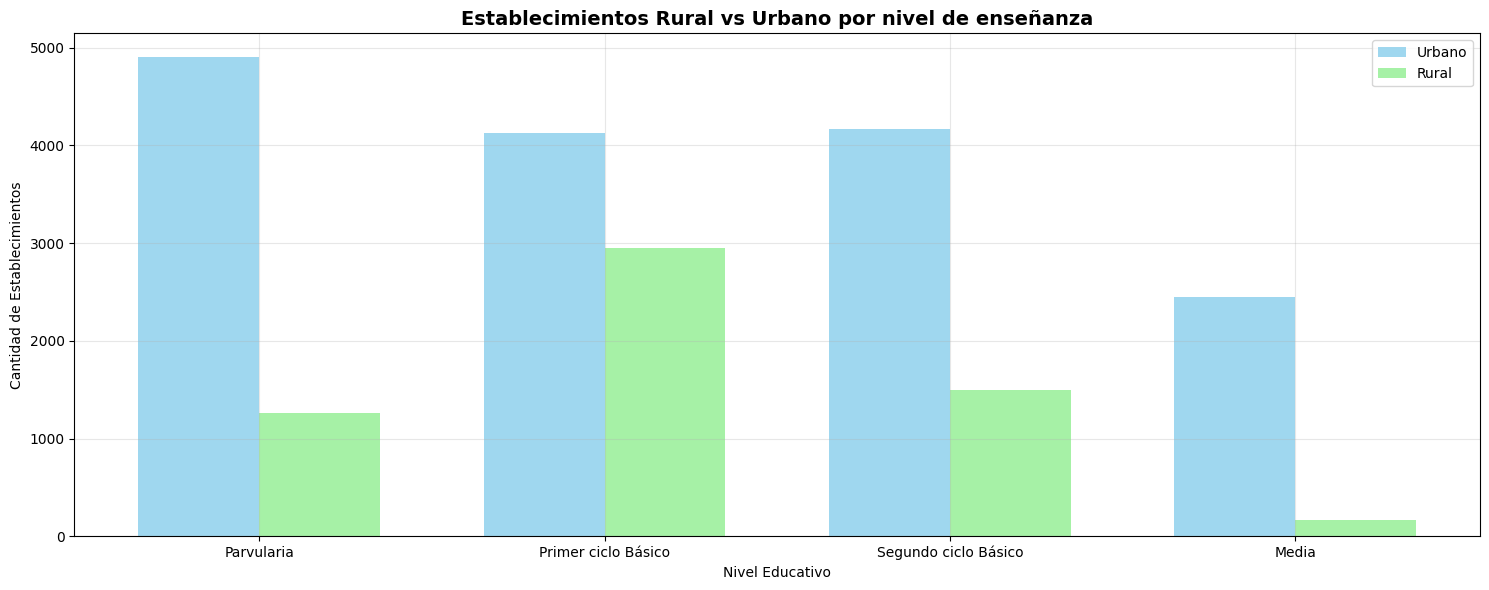

In [405]:
# a.

# Hacemos una función para definir la cantidad de colegios por ruralidad
def tipo_ruralidad(entidad, nombre):
    entidad_urbano = entidad[entidad['DS_RURALIDAD'] == 'Urbano']
    entidad_rural = entidad[entidad['DS_RURALIDAD'] == 'Rural']
    print(f'Cantidad de colegios urbanos en {nombre}: {len(entidad_urbano)}')
    print(f'Cantidad de colegios rurales en {nombre}: {len(entidad_rural)}')
    return len(entidad_urbano), len(entidad_rural)

# Creamos dos listas con los datos necesarios
niveles = ['Parvularia', 'Primer ciclo Básico', 'Segundo ciclo Básico', 'Media']
datasets = [parvularia, primer_ciclo, segundo_ciclo, media]
# Creamos un diccionario con el tipo de establecimiento y su cantidad, para luego graficarlo
resultados = {}
for nombre, df in zip(niveles, datasets):
    urbano, rural = tipo_ruralidad(df, nombre)
    resultados[nombre] = {'Urbano': urbano, 'Rural': rural}

# Graficamos
fig, ax1 = plt.subplots(figsize=(15, 6))
niveles_nombres = list(resultados.keys())
urbanos = [resultados[n]['Urbano'] for n in niveles_nombres]
rurales = [resultados[n]['Rural'] for n in niveles_nombres]
x = np.arange(len(niveles_nombres))
ancho = 0.35
ax1.bar(x - ancho/2, urbanos, ancho, label='Urbano', color='skyblue', alpha=0.8)
ax1.bar(x + ancho/2, rurales, ancho, label='Rural', color='lightgreen', alpha=0.8)
ax1.set_title('Establecimientos Rural vs Urbano por nivel de enseñanza', fontsize=14, fontweight='bold')
ax1.set_xlabel('Nivel Educativo')
ax1.set_ylabel('Cantidad de Establecimientos')
ax1.set_xticks(x)
ax1.set_xticklabels(niveles_nombres, ha='center')
ax1.legend()
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Promedios IVM
El promedio de IVM en Parvularia para establecimientos Rural es 61.07
El promedio de IVM en Parvularia para establecimientos Urbano es 54.02
El promedio de IVM en Primer Ciclo Básica para establecimientos Rural es 43.40
El promedio de IVM en Primer Ciclo Básica para establecimientos Urbano es 43.61
El promedio de IVM en Segundo Ciclo Básica para establecimientos Rural es 36.87
El promedio de IVM en Segundo Ciclo Básica para establecimientos Urbano es 38.99
El promedio de IVM en Media para establecimientos Rural es 19.67
El promedio de IVM en Media para establecimientos Urbano es 20.29


C:\Users\isimo\AppData\Local\Temp\ipykernel_31360\1011784926.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax.boxplot([rural, urbano], labels=['Rural', 'Urbano'],
C:\Users\isimo\AppData\Local\Temp\ipykernel_31360\1011784926.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax.boxplot([rural, urbano], labels=['Rural', 'Urbano'],
C:\Users\isimo\AppData\Local\Temp\ipykernel_31360\1011784926.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax.boxplot([rural, urbano], labels=['Rural', 'Urbano'],
C:\Users\isimo\AppData\Local\Temp\ipykernel_31360\1011784926.py:33: MatplotlibDepr

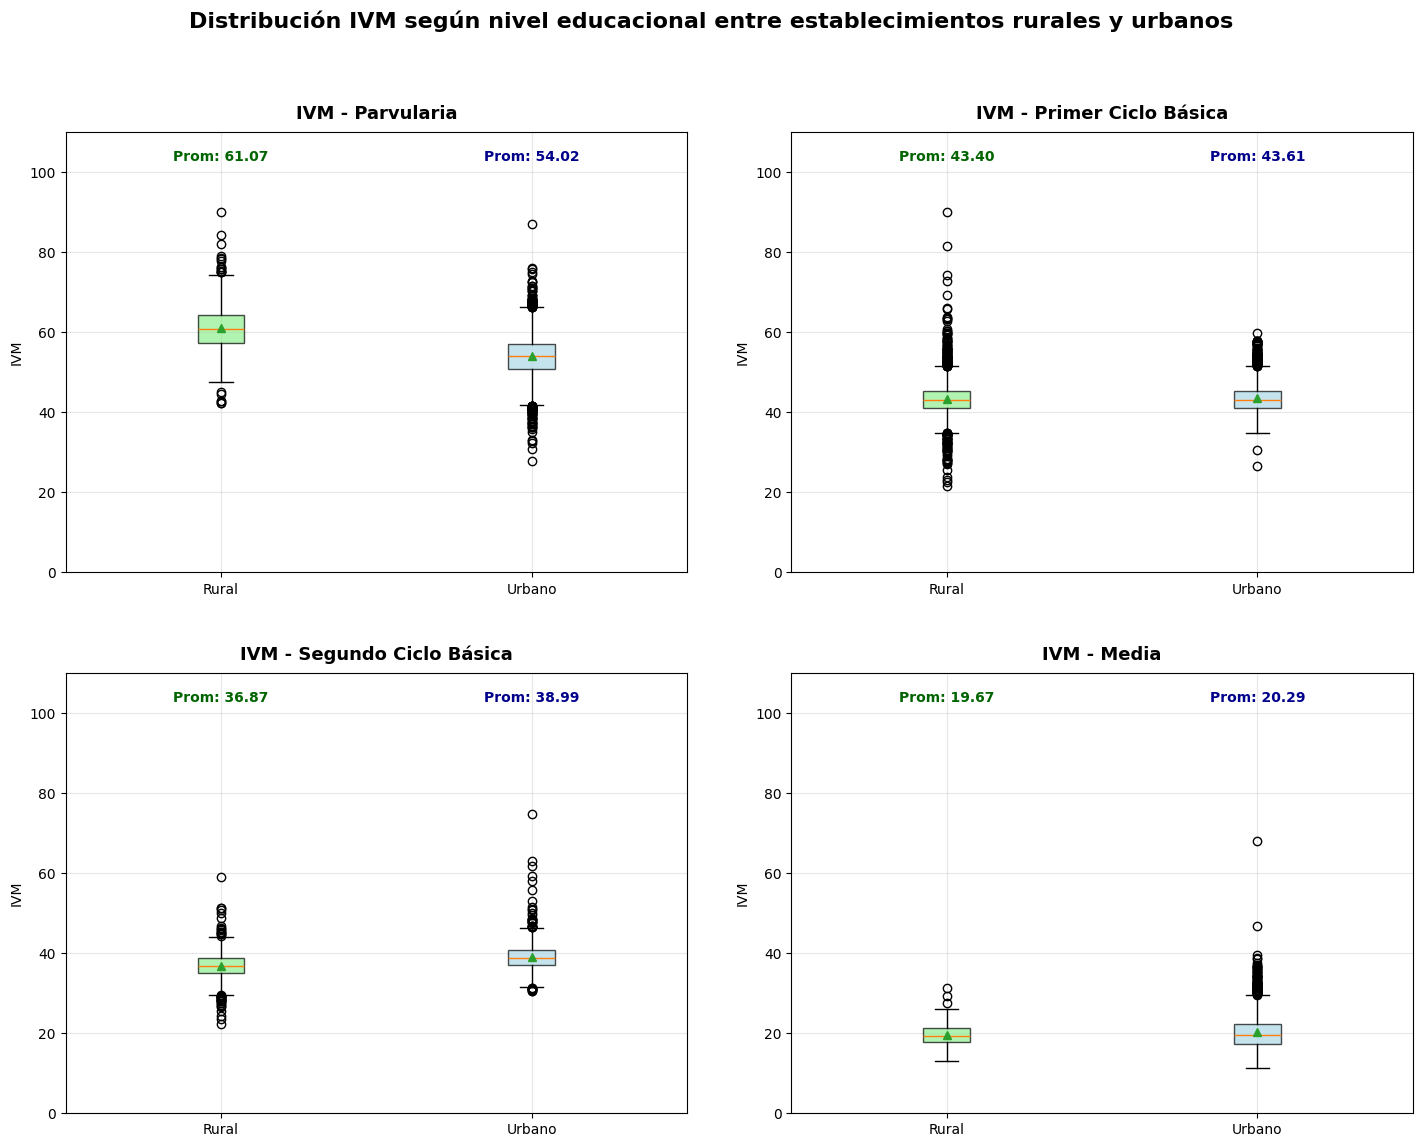

In [406]:
# b. Se asume para esta pregunta que se consulta sobre la columna "ruralidad", 
# queriendo hacer una comparación entre el promedio IVM de los establecimientos rurales vs urbanos 

def sacar_promedio(entidad, nombre):
    promedios = entidad.groupby('DS_RURALIDAD')['IVM Establecimiento'].mean()
    for categoria, promedio in promedios.items():
        print(f'El promedio de IVM en {nombre} para establecimientos {categoria} es {promedio:.2f}')

print("Promedios IVM")
sacar_promedio(parvularia, 'Parvularia')
sacar_promedio(primer_ciclo, 'Primer Ciclo Básica')
sacar_promedio(segundo_ciclo, 'Segundo Ciclo Básica')
sacar_promedio(media, 'Media')

# Separamos por rural/urbano
def preparar_datos_boxplot(entidad):
    rural = entidad[entidad['DS_RURALIDAD'] == 'Rural']['IVM Establecimiento']
    urbano = entidad[entidad['DS_RURALIDAD'] == 'Urbano']['IVM Establecimiento']
    return rural, urbano

datos_parvularia = preparar_datos_boxplot(parvularia)
datos_primer = preparar_datos_boxplot(primer_ciclo)
datos_segundo = preparar_datos_boxplot(segundo_ciclo)
datos_media = preparar_datos_boxplot(media)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()
niveles = ['Parvularia', 'Primer Ciclo Básica', 'Segundo Ciclo Básica', 'Media']
todos_datos = [datos_parvularia, datos_primer, datos_segundo, datos_media]

for ax, datos, nivel in zip(axes, todos_datos, niveles):
    rural, urbano = datos
    box_plot = ax.boxplot([rural, urbano], labels=['Rural', 'Urbano'],
                         patch_artist=True, showmeans=True)
    colors = ['lightgreen', 'lightblue']
    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(f'IVM - {nivel}', fontweight='bold', fontsize=13, pad=10)
    ax.set_ylabel('IVM')
    ax.grid(True, alpha=0.3)
    # Promedios
    prom_rural = rural.mean()
    prom_urbano = urbano.mean()
    # Texto de promedio
    ax.text(1, 103, f'Prom: {prom_rural:.2f}',
            ha='center', fontweight='bold', color='darkgreen', fontsize=10)
    ax.text(2, 103, f'Prom: {prom_urbano:.2f}',
            ha='center', fontweight='bold', color='darkblue', fontsize=10)
    ax.set_ylim(0, 110)

plt.subplots_adjust(wspace=0.25, hspace=0.35)
plt.suptitle('Distribución IVM según nivel educacional entre establecimientos rurales y urbanos',
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(pad=3.5)
plt.show()


Respuesta y comentarios: Gracias a ambas respuestas, a) y b), podemos notar que hay una mayor cantidad de colegios urbanos que rurales en todos los ciclos, siendo la diferencia en cantidad bastante cosniderable para cada ciclo, y el que más parejo es Primer ciclo básico. En IVM urbano y rural el promedio de vulnerabilidad va bastante a la par, sin embargo se "distorsionan" los datos del promedio de los urbanos mucho más que en rurales, exceptuando Primer Ciclo Básico donde hay una clara mayor distorión de datos en el rural.

### 4.2 Tipo de establecimiento (0.7 pts)

* ¿Cómo es la distribución del IVM promedio de los establecimientos según tipo de dependencia y nivel de enseñanza? 

In [407]:
# Primero, veamos cuáles son los tipo de dependencias que se tienen en el dataset:

p = set(parvularia['DS_TIPO_DEPENDENCIA'].unique())
pc = set(primer_ciclo['DS_TIPO_DEPENDENCIA'].unique())
sc = set(segundo_ciclo['DS_TIPO_DEPENDENCIA'].unique())
m = set(media['DS_TIPO_DEPENDENCIA'].unique())

unicos = p | pc | sc | m 
print(unicos)

interseccion = p & pc & sc & m
print(interseccion)

{'Particular Subvencionado', 'Servicio Local de Educación(SLE)', 'Municipal DAEM', 'Administración Delegada (C. P. 3166)', 'Corporación Municipal'}
{'Municipal DAEM', 'Particular Subvencionado', 'Corporación Municipal', 'Servicio Local de Educación(SLE)'}



Cantidad de establecimientos en Parvularia según tipo de dependencia y ruralidad:

DS_RURALIDAD                      Rural  Urbano
DS_TIPO_DEPENDENCIA                            
Corporación Municipal                77     294
Municipal DAEM                      752     758
Particular Subvencionado            203    3225
Servicio Local de Educación(SLE)    228     626


Cantidad de establecimientos en Primer Ciclo Básica según tipo de dependencia y ruralidad:

DS_RURALIDAD                          Rural  Urbano
DS_TIPO_DEPENDENCIA                                
Administración Delegada (C. P. 3166)      0       1
Corporación Municipal                    92     295
Municipal DAEM                         1637     778
Particular Subvencionado                608    2400
Servicio Local de Educación(SLE)        617     654


Cantidad de establecimientos en Segundo Ciclo Básica según tipo de dependencia y ruralidad:

DS_RURALIDAD                          Rural  Urbano
DS_TIPO_DEPENDENCIA    

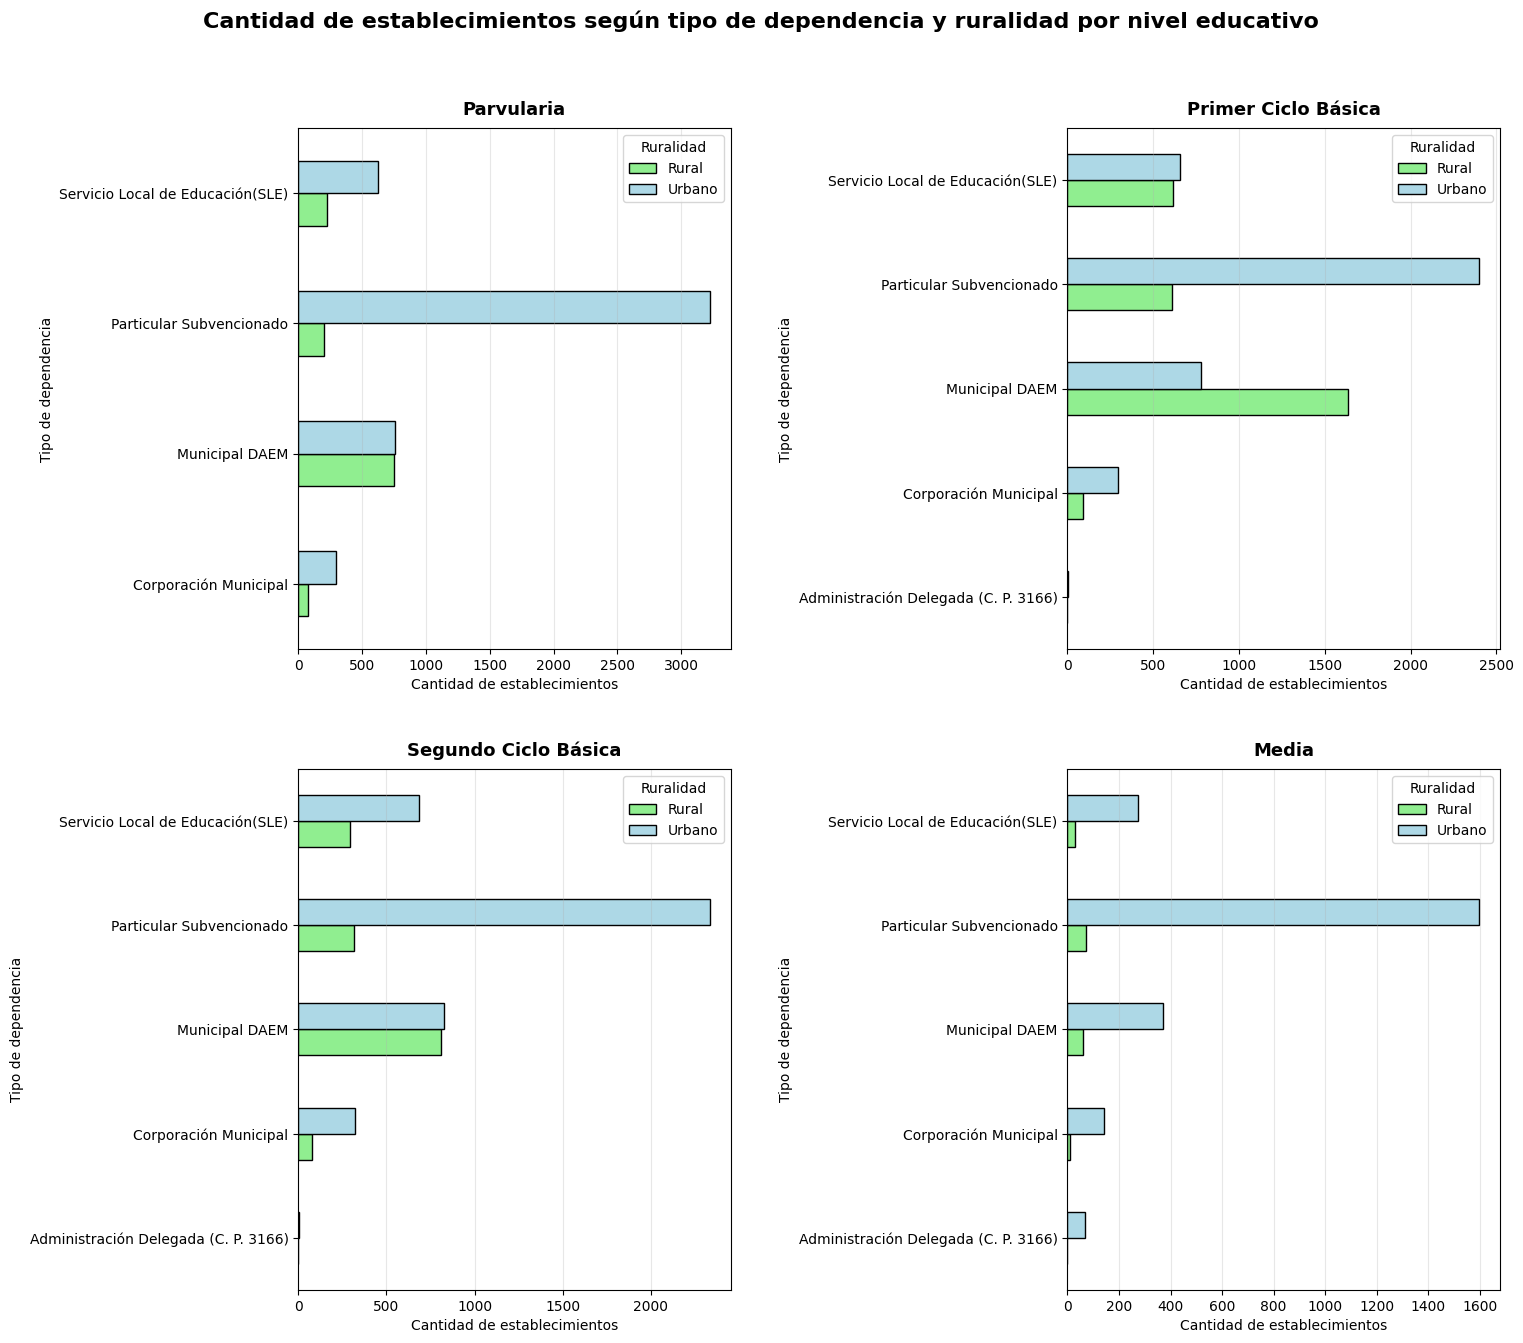

In [408]:
# Veamos la cantidad de establecimientos según su tipo de dependencia, separándolo por ciclos ruralidad.

def contar_dependencia_ruralidad(entidad, nombre):
    conteo = entidad.groupby(['DS_TIPO_DEPENDENCIA', 'DS_RURALIDAD']).size().unstack(fill_value=0)
    print(f'\nCantidad de establecimientos en {nombre} según tipo de dependencia y ruralidad:\n')
    print(f'{conteo}\n')
    return conteo

conteo_parvularia = contar_dependencia_ruralidad(parvularia, 'Parvularia')
conteo_primer = contar_dependencia_ruralidad(primer_ciclo, 'Primer Ciclo Básica')
conteo_segundo = contar_dependencia_ruralidad(segundo_ciclo, 'Segundo Ciclo Básica')
conteo_media = contar_dependencia_ruralidad(media, 'Media')

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()
niveles = ['Parvularia', 'Primer Ciclo Básica', 'Segundo Ciclo Básica', 'Media']
todos_conteos = [conteo_parvularia, conteo_primer, conteo_segundo, conteo_media]

for ax, conteo, nivel in zip(axes, todos_conteos, niveles):
    conteo.plot(kind='barh', ax=ax, color=['lightgreen', 'lightblue'], edgecolor='black')
    ax.set_title(f'{nivel}', fontweight='bold', fontsize=13, pad=10)
    ax.set_xlabel('Cantidad de establecimientos')
    ax.set_ylabel('Tipo de dependencia')
    ax.legend(title='Ruralidad')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Cantidad de establecimientos según tipo de dependencia y ruralidad por nivel educativo',
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(pad=3.5)
plt.show()


Promedios de IVM en Parvularia según tipo de dependencia:
  - Corporación Municipal: 54.41
  - Municipal DAEM: 59.04
  - Particular Subvencionado: 53.57
  - Servicio Local de Educación(SLE): 57.20

Promedios de IVM en Primer Ciclo Básica según tipo de dependencia:
  - Administración Delegada (C. P. 3166): 40.22
  - Corporación Municipal: 45.01
  - Municipal DAEM: 43.66
  - Particular Subvencionado: 42.72
  - Servicio Local de Educación(SLE): 44.71

Promedios de IVM en Segundo Ciclo Básica según tipo de dependencia:
  - Administración Delegada (C. P. 3166): 40.52
  - Corporación Municipal: 39.87
  - Municipal DAEM: 37.87
  - Particular Subvencionado: 38.50
  - Servicio Local de Educación(SLE): 38.61

Promedios de IVM en Media según tipo de dependencia:
  - Administración Delegada (C. P. 3166): 23.87
  - Corporación Municipal: 23.68
  - Municipal DAEM: 20.90
  - Particular Subvencionado: 19.16
  - Servicio Local de Educación(SLE): 22.87


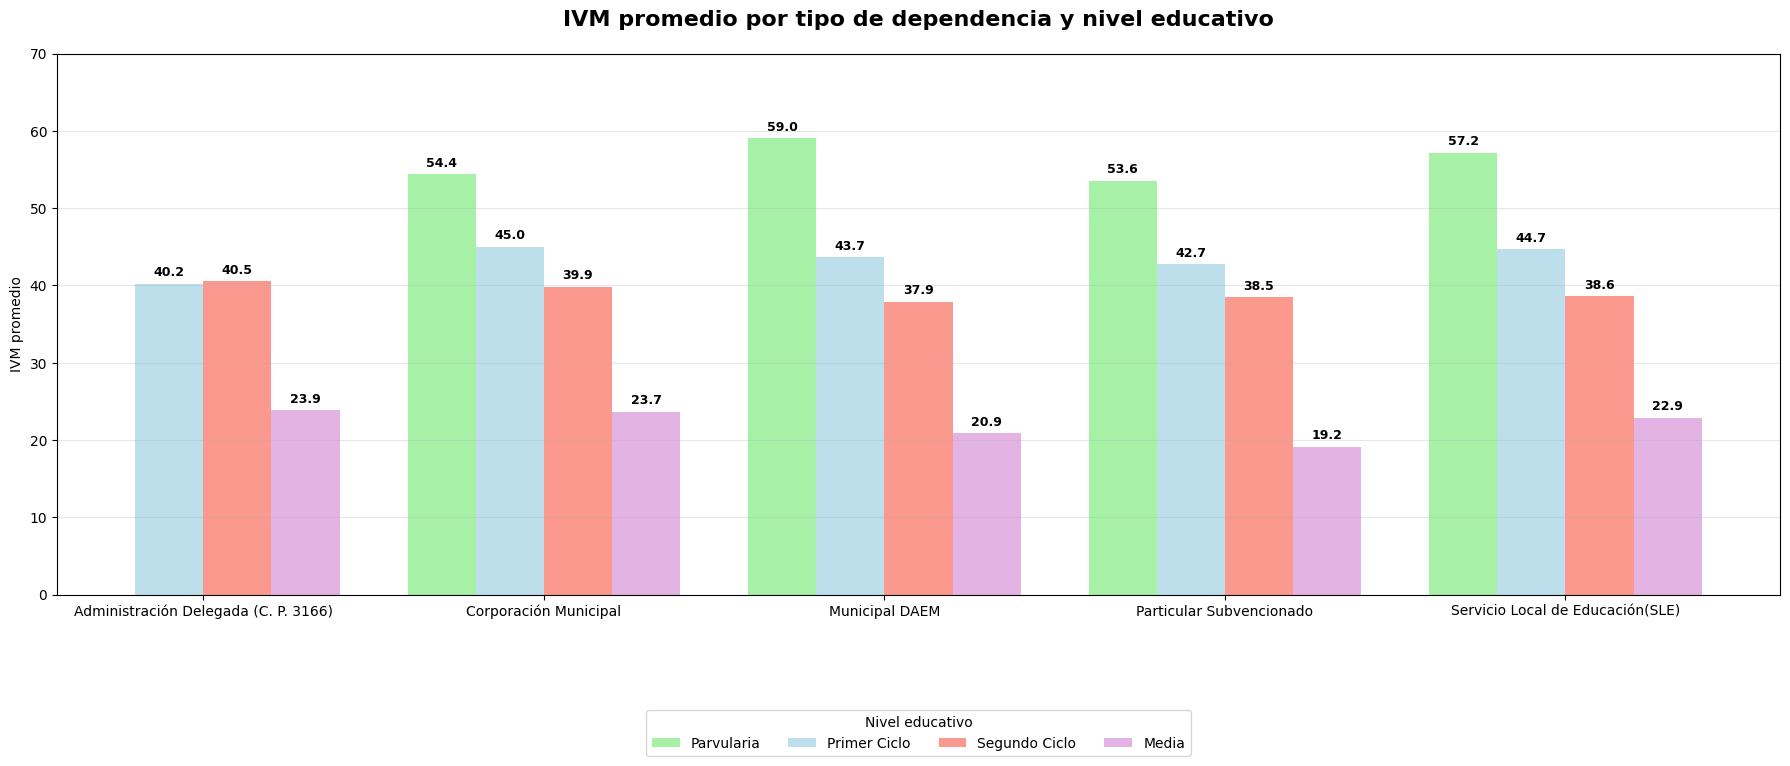

In [409]:
# Respuesta

def sacar_promedio_dependencia(entidad, nombre):
    promedios = entidad.groupby('DS_TIPO_DEPENDENCIA')['IVM Establecimiento'].mean()
    print(f'\nPromedios de IVM en {nombre} según tipo de dependencia:')
    for tipo, promedio in promedios.items():
        print(f'  - {tipo}: {promedio:.2f}')

sacar_promedio_dependencia(parvularia, 'Parvularia')
sacar_promedio_dependencia(primer_ciclo, 'Primer Ciclo Básica')
sacar_promedio_dependencia(segundo_ciclo, 'Segundo Ciclo Básica')
sacar_promedio_dependencia(media, 'Media')

niveles = ['Parvularia', 'Primer Ciclo', 'Segundo Ciclo', 'Media']
todos_dfs = [parvularia, primer_ciclo, segundo_ciclo, media]
todas_dependencias = set()
for df in todos_dfs:
    todas_dependencias.update(df['DS_TIPO_DEPENDENCIA'].unique())
dependencias = sorted(todas_dependencias)

# Consulta a la IA generativa: 'Tengo variables que no existen en todos mis datasets a graficar, ¿cómo puedo manejar esto?'

datos_grafico = []
for df in todos_dfs:
    promedios_nivel = df.groupby('DS_TIPO_DEPENDENCIA')['IVM Establecimiento'].mean()
    fila = [promedios_nivel.get(dep, np.nan) for dep in dependencias]
    datos_grafico.append(fila)

df_grafico = pd.DataFrame(datos_grafico, index=niveles, columns=dependencias)
fig, ax = plt.subplots(figsize=(18, 8))
x = np.arange(len(dependencias))
width = 0.2  
colors = ['lightgreen', 'lightblue', 'salmon', 'plum']

for i, nivel in enumerate(niveles):
    valores = df_grafico.loc[nivel].values
    mascara = ~np.isnan(valores)
    x_pos = x[mascara] + i * width
    valores_pos = valores[mascara]
    bars = ax.bar(x_pos, valores_pos, width=width, color=colors[i], alpha=0.8, label=nivel)
    for bar, valor in zip(bars, valores_pos):
        ax.text(bar.get_x() + bar.get_width()/2, valor + 1, f'{valor:.1f}', 
                ha='center', fontsize=9, fontweight='bold')

ax.set_title('IVM promedio por tipo de dependencia y nivel educativo', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('IVM promedio')
ax.set_ylim(0, max(df_grafico.max().max() + 10, 70))
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(dependencias, ha='center', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Nivel educativo', bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=4)
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()

Respuesta y comentarios:

Notamos que, a niveles generales, Parvularia tienen el mayor promedio IVM de todos en cualquier tipo de dependencia educativo, y media es donde menos IVM promedio se tiene. Entre el segundo ciclo de básica y la media es la mayor bajada de IVM promedio en todos los establecimientos, además entre el primer y segundo ciclo de básica es donde menos da el salto el promedio en bajada, no bajando más de un 7%. Respecto a cómo se separan para la investigación ests grupos, el segundo grupo (segundo ciclo básica y media) tiene mayor vulnerabilidad en Administración Delegada y menor en Municipal DAEM (sacando el promedio entre ambos promedios). En cambio, en el primer grupo (donde Adm. Delegada queda fuera al no tener parvularia), el con mayor IVM promedio es Municipal DAEM, y con menor es Particular Subvencionado. Esto provoca un interesante duda: ¿por qué en el primer grupo (parvularia, primer ciclo básico) Municipal DAEM es el con mayor IVM, sin embargo totalmente lo contrario ocurre en el segundo grupo (segundo ciclo básico, media)?

### 4.3 Pregunta Bono: Dimensiones de vulnerabilidad (1 punto)

Para los niveles de enseñanza Parvularia y Básica Primer ciclo (1-4º), tenemos información sobre distintas dimensiones de que se utilizan para calcular el IVM, como condición socioeconómica familiar y comunal, salud, etc. 

* Para todo Chile, en promedio, ¿cuál es la dimensión con mayor puntaje de IVM para cada uno de estos dos niveles de enseñanza?

In [410]:
# Respuestas

Respuesta y comentarios:

## 5. Agrupación de bases de datos (2 puntos)

El objetivo de esta sección será agrupar los establecimientos según la comuna en la que se encuentran para obtener un resumen general sobre la vulnerabilidad escolar en cada una de ellas. Al finalizar esta sección, tendremos un nuevo DataFrame `agg_comunal` que contenga, al menos, la siguiente información:

* Comuna (nombre y ID)
* Región (ID)
* Cantidad de establecimientos rurales de la comuna
* Cantidad de establecimientos urbanos de la comuna
* Cantidad total de establecimientos de la comuna
* Porcentaje de establecimientos rurales
* IVM Promedio Parvularia de la comuna
* IVM Promedio Básica Primer Ciclo de la comuna
* IVM Promedio Básica Segundo Ciclo de la comuna
* IVM Promedio Media de la comuna
* Objeto geometry de GeoPandas correspondiente al polígono de la comuna respectiva

Armaremos este DataFrame paso a paso.

### 5.1 Cálculo de IVM promedio por comuna (0.8 pts)

Primero, para cada uno sus 4 DataFrames, calcule el promedio de la columna `IVM Establecimiento` según comuna. Almacene este valor en una nueva columna llamada `IVM Promedio {NIVEL DE ENSEÑANZA}` (por ejemplo, para enseñanza parvularia, cree la columna `IVM Promedio Parvularia`).

Junte los 4 resultados que obtuvo en un solo DataFrame `ivm_comunal` que contenga:
* Comuna (nombre y ID)
* Región (ID)
* IVM Promedio Parvularia de la comuna
* IVM Promedio Básica Primer Ciclo de la comuna
* IVM Promedio Básica Segundo Ciclo de la comuna
* IVM Promedio Media de la comuna

Ponga siempre atención al tamaño de sus DataFrames: como estamos agrupando comunalmente, estos siempre debiesen tener una cantidad de filas igual a las comunas de Chile.

In [411]:
# Primero, crearemos ivm_comunal que contenga las columnas Comuna (nombre e ID) y Región (ID), 
# esto con el objetivo de ir agregándole los resultados posteriores de promedios por comuna

# Nos aseguramos de considerar el total de las comunas de cada dataset
p = parvularia[['DS_COMUNA_ESTABLE', 'ID_COMUNA_ESTABLE', 'ID_REGION_ESTABLE']].drop_duplicates()
pc = primer_ciclo[['ID_COMUNA_ESTABLE', 'DS_COMUNA_ESTABLE', 'ID_REGION_ESTABLE']].drop_duplicates()
sc = segundo_ciclo[['ID_COMUNA_ESTABLE', 'DS_COMUNA_ESTABLE', 'ID_REGION_ESTABLE']].drop_duplicates()
m = media[['ID_COMUNA_ESTABLE', 'DS_COMUNA_ESTABLE', 'ID_REGION_ESTABLE']].drop_duplicates()
todas_comunas = pd.concat([p, pc, sc, m]).drop_duplicates(subset='ID_COMUNA_ESTABLE')

ivm_comunal = todas_comunas.reset_index(drop=True)
ivm_comunal.head()

,DS_COMUNA_ESTABLE,ID_COMUNA_ESTABLE,ID_REGION_ESTABLE
0,Arica,15101,15
1,Putre,15201,15
2,Iquique,1101,1
3,Huara,1404,1
4,Camiña,1402,1


In [412]:
# Creamos una función para calculcar el promedio IVM por comuna y luego agregarlo al dataframe

def agregar_promedio_ivm(df_base, df_nivel, nombre_columna):
    promedio = df_nivel.groupby('ID_COMUNA_ESTABLE')['IVM Establecimiento'].mean()
    promedio = promedio.rename(nombre_columna).reset_index()
    df_base = df_base.merge(promedio, on='ID_COMUNA_ESTABLE', how='left')
    return df_base

ivm_comunal = agregar_promedio_ivm(ivm_comunal, parvularia, 'IVM Promedio Parvularia')
ivm_comunal = agregar_promedio_ivm(ivm_comunal, primer_ciclo, 'IVM Promedio Primer Ciclo Básica')
ivm_comunal = agregar_promedio_ivm(ivm_comunal, segundo_ciclo, 'IVM Promedio Segundo Ciclo Básica')
ivm_comunal = agregar_promedio_ivm(ivm_comunal, media, 'IVM Promedio Media')

ivm_comunal.head()

,DS_COMUNA_ESTABLE,ID_COMUNA_ESTABLE,ID_REGION_ESTABLE,IVM Promedio Parvularia,IVM Promedio Primer Ciclo Básica,IVM Promedio Segundo Ciclo Básica,IVM Promedio Media
0,Arica,15101,15,52.904976,47.300547,38.244745,20.125566
1,Putre,15201,15,60.845008,52.463942,36.210464,25.794290
2,Iquique,1101,1,50.882970,45.131982,39.182182,22.109517
3,Huara,1404,1,66.630747,45.467033,37.646088,20.097634
4,Camiña,1402,1,68.812360,46.127984,34.998365,17.966318


In [413]:
print(f'Comunas totales consideradas en el dataframe: {len(ivm_comunal)}\n')

print('A 2025, Chile tiene 346 comunas, sin embargo, como se trabajó con las\ncomunas que ya venían de los datasets, se asume que una comuna o no está\nsiendo considerada para el estudio, o tiene solo datos nulos, y se toma\ncomo exitoso el dataframe creado.')

Comunas totales consideradas en el dataframe: 345

A 2025, Chile tiene 346 comunas, sin embargo, como se trabajó con las
comunas que ya venían de los datasets, se asume que una comuna o no está
siendo considerada para el estudio, o tiene solo datos nulos, y se toma
como exitoso el dataframe creado.


### 5.2 Establecimientos por comuna y ruralidad (0.8 pts)

Ahora contaremos la cantidad de establecimientos por comuna según ruralidad. Como buscamos la cantidad total de establecimientos, consideramos establecimientos de todos los niveles educacionales vistos. Para esto, combine los 4 DataFrames que cargó y genere un nuevo DataFrame `estab_comunal` que contenga:

* Comuna (ID)
* Cantidad de establecimientos rurales
* Cantidad de establecimientos urbanos
* Cantidad total de establecimientos
* Porcentaje de establecimientos rurales (Establecimientos rurales / Total establecimientos * 100)

Tenga en cuenta de que pueden aparecer establecimientos duplicados al combinar estos 4 DataFrames (por ejemplo, establecimientos que imparten múltiples niveles de enseñanza, desde 1º básico hasta 4º medio). Preocúpese de manejar estos casos antes de agrupar sus datos según ruralidad.

In [ ]:
# Primero, combinamos los cuatro niveles educativos y eliminamos duplicaods
todos_estab = pd.concat([parvularia, primer_ciclo, segundo_ciclo, media])
todos_estab = todos_estab.drop_duplicates(subset=['ID_RBD'])

conteo = todos_estab.groupby(['ID_COMUNA_ESTABLE', 'DS_RURALIDAD']).size().unstack(fill_value=0)
estab_comunal = todas_comunas[['ID_COMUNA_ESTABLE', 'DS_COMUNA_ESTABLE']].merge(
    conteo, left_on='ID_COMUNA_ESTABLE', right_index=True, how='left')

# Rellenamos vacíos con 0s
estab_comunal['Cant. de establecimientos rurales'] = estab_comunal['Rural'].fillna(0).astype(int)
estab_comunal['Cant. de establecimientos urbanos'] = estab_comunal['Urbano'].fillna(0).astype(int)


estab_comunal['Cant. total de establecimientos'] = (estab_comunal['Cant. de establecimientos rurales'] 
                                                       + estab_comunal['Cant. de establecimientos urbanos'])
estab_comunal['% Establecimientos rurales'] = (estab_comunal['Cant. de establecimientos rurales'] 
                                               / estab_comunal['Cant. total de establecimientos'] * 100)
estab_comunal = estab_comunal[['ID_COMUNA_ESTABLE', 'Cant. de establecimientos rurales', 'Cant. de establecimientos urbanos',
                               'Cant. total de establecimientos', '% Establecimientos rurales']]

estab_comunal.head()


,ID_COMUNA_ESTABLE,Cant. de establecimientos rurales,Cant. de establecimientos urbanos,Cant. total de establecimientos,% Establecimientos rurales
0,15101,9,91,100,9.000000
33,15201,6,0,6,100.000000
34,1101,3,81,84,3.571429
49,1404,12,0,12,100.000000
52,1402,10,0,10,100.000000


In [416]:
print(f'Comunas totales consideradas en el dataframe: {len(estab_comunal)}\n')

print('A 2025, Chile tiene 346 comunas, sin embargo, como se trabajó con las\ncomunas que ya venían de los datasets, se asume que una comuna o no está\nsiendo considerada para el estudio, o tiene solo datos nulos, y se toma\ncomo exitoso el dataframe creado.')

Comunas totales consideradas en el dataframe: 345

A 2025, Chile tiene 346 comunas, sin embargo, como se trabajó con las
comunas que ya venían de los datasets, se asume que una comuna o no está
siendo considerada para el estudio, o tiene solo datos nulos, y se toma
como exitoso el dataframe creado.


### 5.3 Unión de bases de datos y polígonos (0.4 pts)

Finalmente, vamos a generar el DataFrame `agg_comunal` con la información de los dos previos DataFrames creados.
Combine la información de las dos secciones anteriores para crear su base de datos unificada. Por último, agregue la columna `geometry` con la información geográfica de cada comuna.

In [ ]:
# Primero, hacemos merge a los df creados en 5.1 y 5.2
agg_comunal = pd.merge(ivm_comunal, estab_comunal, how='left', on='ID_COMUNA_ESTABLE')
agg_comunal.head()

,DS_COMUNA_ESTABLE,ID_COMUNA_ESTABLE,ID_REGION_ESTABLE,IVM Promedio Parvularia,IVM Promedio Primer Ciclo Básica,IVM Promedio Segundo Ciclo Básica,IVM Promedio Media,Cant. de establecimientos rurales,Cant. de establecimientos urbanos,Cant. total de establecimientos,% Establecimientos rurales
0,Arica,15101,15,52.904976,47.300547,38.244745,20.125566,9,91,100,9.000000
1,Putre,15201,15,60.845008,52.463942,36.210464,25.794290,6,0,6,100.000000
2,Iquique,1101,1,50.882970,45.131982,39.182182,22.109517,3,81,84,3.571429
3,Huara,1404,1,66.630747,45.467033,37.646088,20.097634,12,0,12,100.000000
4,Camiña,1402,1,68.812360,46.127984,34.998365,17.966318,10,0,10,100.000000


In [424]:
# Veamos los datos de comunas que hicimos en el ítem 3

print(f'Comunas en el dataframe: {len(comunas)}')
comunas.head()

Comunas en el dataframe: 346


,objectid,shape_leng,dis_elec,cir_sena,cod_comuna,codregion,st_area_sh,st_length_,Region,Comuna,Provincia,geometry
0,48,170038.624165,16,8,6204,6,9.685774e+08,206184.271675,Región del Libertador Bernardo O'Higgins,Marchigüe,Cardenal Caro,"POLYGON ((-71.80071 -34.20728, -71.79992 -34.2..."
1,29,125730.104795,15,8,6102,6,4.157446e+08,151911.576827,Región del Libertador Bernardo O'Higgins,Codegua,Cachapoal,"POLYGON ((-70.35293 -33.95263, -70.35243 -33.9..."
2,30,63026.084422,15,8,6103,6,1.448565e+08,76355.326122,Región del Libertador Bernardo O'Higgins,Coinco,Cachapoal,"POLYGON ((-70.90058 -34.23703, -70.90063 -34.2..."
3,31,89840.903562,15,8,6104,6,3.256572e+08,108874.623150,Región del Libertador Bernardo O'Higgins,Coltauco,Cachapoal,"POLYGON ((-71.02492 -34.17053, -71.0232 -34.17..."
4,78,122626.493264,23,11,9121,9,6.990727e+08,156680.410681,Región de La Araucanía,Cholchol,Cautín,"POLYGON ((-72.95898 -38.46877, -72.95797 -38.4..."


Notamos que aquí sí están las 346 comunas, por lo cual rellenaremos aquella comuna sin datos con NaN

In [427]:
comunas = comunas.rename(columns={'cod_comuna': 'ID_COMUNA_ESTABLE'})
agg_comunal = comunas[['ID_COMUNA_ESTABLE', 'geometry']].merge(ivm_comunal, how='left', on='ID_COMUNA_ESTABLE').merge(
    estab_comunal, how='left', on='ID_COMUNA_ESTABLE')

agg_comunal.head()

,ID_COMUNA_ESTABLE,geometry,DS_COMUNA_ESTABLE,ID_REGION_ESTABLE,IVM Promedio Parvularia,IVM Promedio Primer Ciclo Básica,IVM Promedio Segundo Ciclo Básica,IVM Promedio Media,Cant. de establecimientos rurales,Cant. de establecimientos urbanos,Cant. total de establecimientos,% Establecimientos rurales
0,6204,"POLYGON ((-71.80071 -34.20728, -71.79992 -34.2...",Marchihue,6.0,61.711865,43.651336,38.967168,18.400982,8.0,3.0,11.0,72.727273
1,6102,"POLYGON ((-70.35293 -33.95263, -70.35243 -33.9...",Codegua,6.0,58.123433,44.076059,39.515944,19.819330,5.0,4.0,9.0,55.555556
2,6103,"POLYGON ((-70.90058 -34.23703, -70.90063 -34.2...",Coinco,6.0,60.267082,42.480840,38.244919,19.997974,4.0,2.0,6.0,66.666667
3,6104,"POLYGON ((-71.02492 -34.17053, -71.0232 -34.17...",Coltauco,6.0,59.128168,43.735337,40.007292,20.012614,12.0,5.0,17.0,70.588235
4,9121,"POLYGON ((-72.95898 -38.46877, -72.95797 -38.4...",Cholchol,9.0,66.139694,44.909401,37.591292,17.796872,25.0,6.0,31.0,80.645161


In [428]:
print(f'Cantidad de comunas: {len(agg_comunal)}')

Cantidad de comunas: 346


## 6. Análisis de vulnerabilidad por comuna (1.5 puntos)

### 6.1 Mapa de calor (0.8 pts)

Genere mapas de calor de las comunas de Chile según el IVM promedio de los establecimientos educacionales. Realice esto para cada etapa de enseñanza (Parvularia, Básica 1, Básica 2 y Media). Analice y comente sus resultados:
* ¿Cómo se diferencia la vulnerabilidad en distintos sectores del país según nivel de enseñanza?

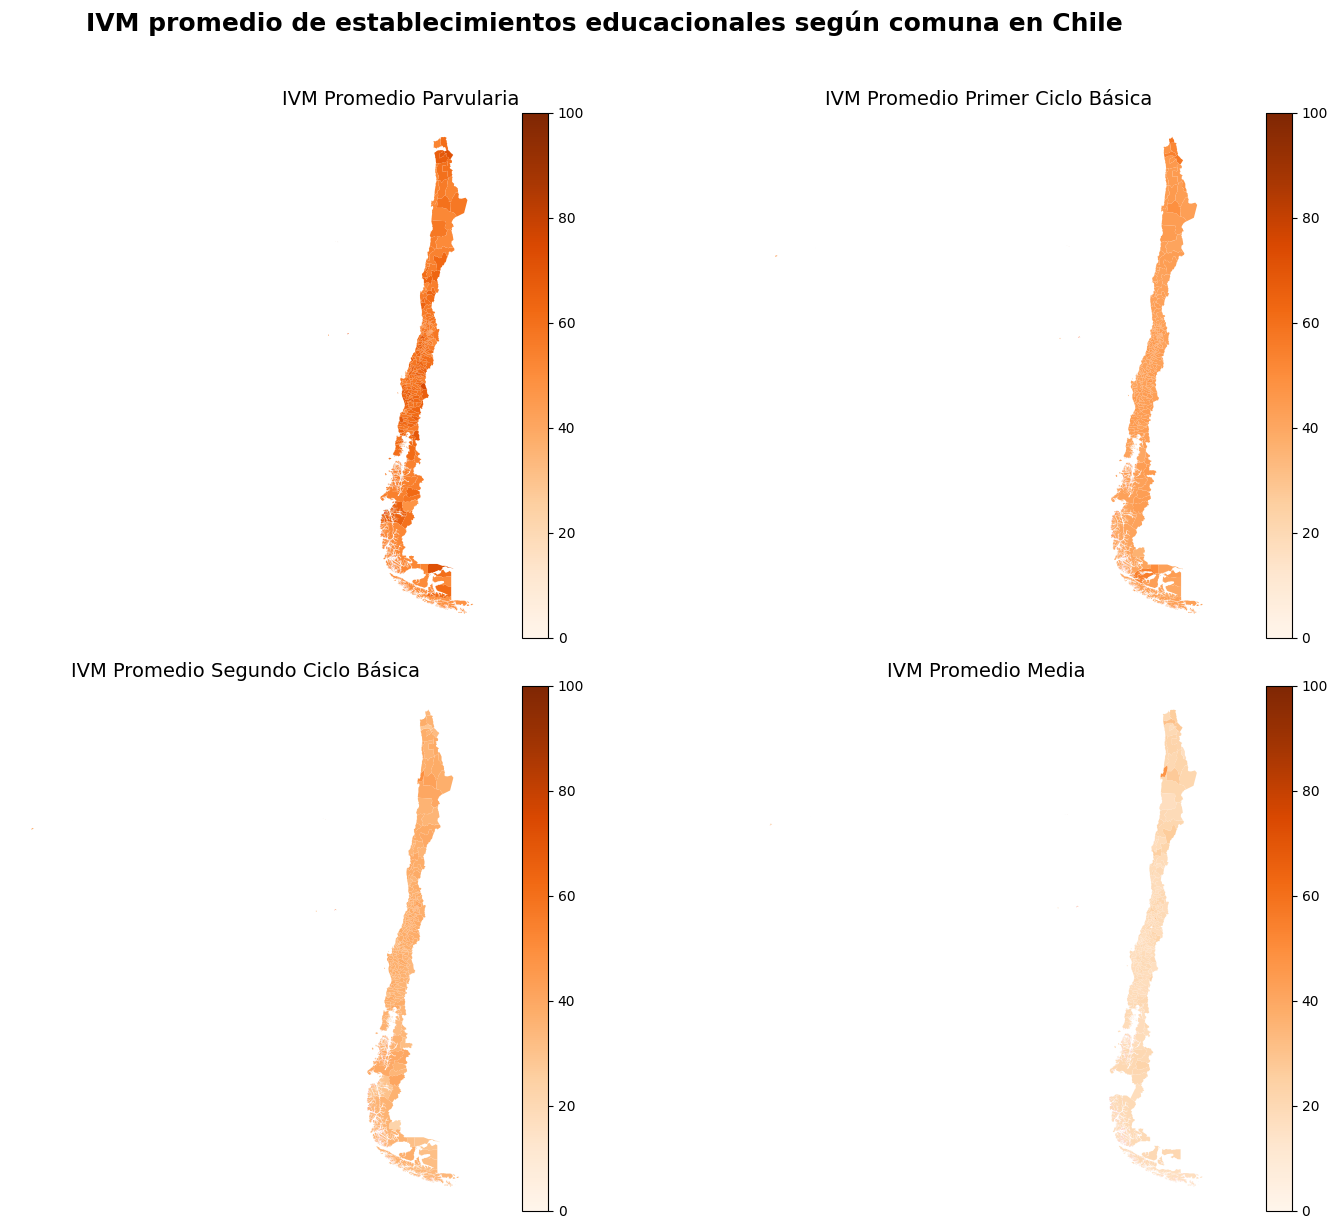

In [442]:
var = ['IVM Promedio Parvularia', 'IVM Promedio Primer Ciclo Básica', 'IVM Promedio Segundo Ciclo Básica', 'IVM Promedio Media']
vmin, vmax = 0, 100
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
for ax, v in zip(axes, var):
    agg_comunal.plot(column=v, cmap='Oranges', linewidth=0.8, ax=ax, legend=True, vmin=vmin, vmax=vmax)
    ax.set_title(v, fontsize=14)
    ax.axis('off')
fig.suptitle('IVM promedio de establecimientos educacionales según comuna en Chile', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Comentarios y análisis:

### 6.2 Relación entre ruralidad comunal y vulnerabilidad (0.7 pts)

En la sección **5.2** definimos el **porcentaje de ruralidad** de cada comuna según la cantidad de establecimientos rurales en cada una. Analice y visualice los datos en `agg_comunal` para responder la siguiente pregunta:

* ¿Hay alguna correlación entre el IVM promedio y el porcentaje de ruralidad en las comunas de Chile?

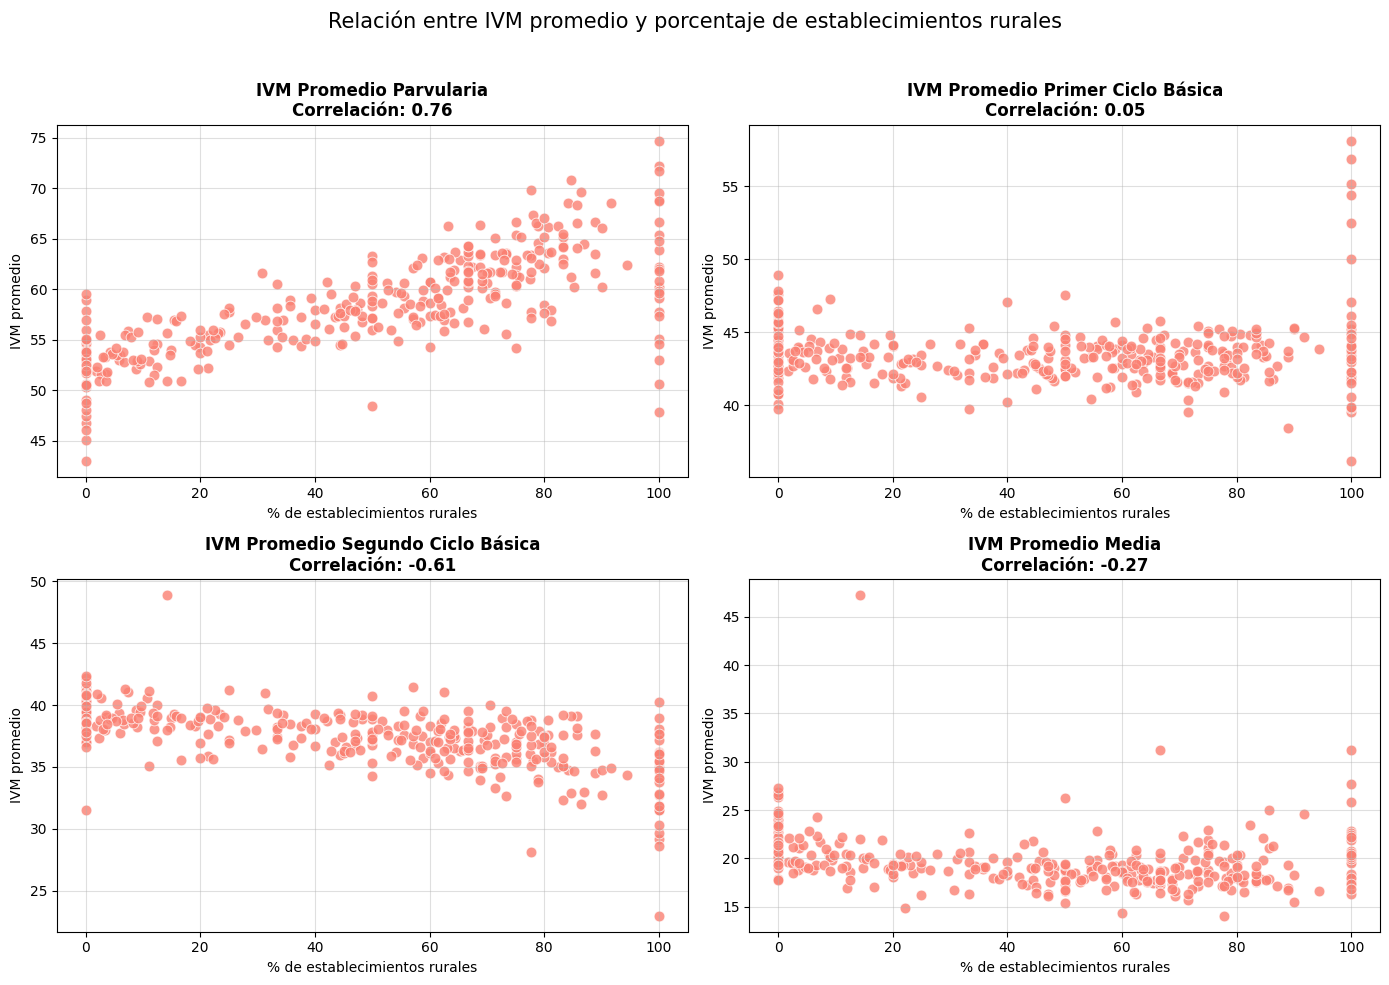

In [ ]:
niveles = ['IVM Promedio Parvularia', 'IVM Promedio Primer Ciclo Básica', 'IVM Promedio Segundo Ciclo Básica', 'IVM Promedio Media']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for ax, nivel in zip(axes, niveles):
    sns.scatterplot(data=agg_comunal, x='% Establecimientos rurales', y=nivel, ax=ax, color='salmon', edgecolor='white', s=60, alpha=0.8)
    corr = agg_comunal[nivel].corr(agg_comunal['% Establecimientos rurales'])
    ax.set_title(f'{nivel}\nCorrelación: {corr:.2f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('% de establecimientos rurales')
    ax.set_ylabel('IVM promedio')
    ax.grid(True, linestyle='-', alpha=0.4)

plt.suptitle("Relación entre IVM promedio y porcentaje de establecimientos rurales", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print('Correlaciones entre el IVM promedio y el % de establecimientos rurales:\n')
for col in niveles:
    corr = agg_comunal['% Establecimientos rurales'].corr(agg_comunal[col])
    print(f"{col}: {corr}")

## 7 Pregunta Bono (2 punto)

* Proponga una pregunta de análisis que le interese responder con los datos de cualquiera de las bases de datos leídas o generadas durante esta Tarea.
Respóndala de la misma forma que las preguntas anteriores, generando una o varias visualizaciones y analizando sus resultados. Justifique 

**Recomendación**: Trate de proponer una pregunta que justifique el uso de agregación de datos y visualización. En otras palabras, que
no pueda ser respondida directamente sin el uso de gráficos (por ejemplo, *"¿cuál es el establecimiento con mayor IVM?"* puede ser respondida con una búsqueda rápida en el DataFrame).

**Pregunta propuesta:**

In [ ]:
# respuesta